# My First EDA - Apple messy data:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("raw_dataset.csv")

## Step 1 - Understanding the data:

In [2]:
data.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_MAD,Current_Price_USD,Current_Price_MAD,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,24/08/2025,amazon,Watch,Apple Watch Series 6 (44mm),new,429,3989.7,255.69,2377.92,40.4,NaN,Low Stock,4.4,2671
1,2026-04-30,Flipkart,iPhone,iPhone 15 128GB,New,799,7430.7,594.58,5529.59,25.6,NaN,In Stock,4.8,2828
2,2025-02-20,Amazon,Mac,MacBook Pro 14-inch M2 Pro 512GB,New,1999,18590.7,1802.37,16762.04,9.8,NaN,In Stock,4.7,1515
3,Sep 26 2023,AMAZON,Watch,Apple Watch Ultra,Renewed/Refurbished,799,7430.7,556.0,5170.80,30.4,NaN,In Stock,3.9,1597
4,2025-08-13,FLIPKART,iPad,iPad Pro 11-inch (M1) 128GB,New,799,7430.7,477.03,4436.38,40.3,NaN,Out of Stock,4.2,2983


In [3]:
data.shape

(82000, 14)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 82000 entries, 0 to 81999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               82000 non-null  str    
 1   Platform           82000 non-null  str    
 2   Product_Category   82000 non-null  str    
 3   Model_Name         82000 non-null  str    
 4   Condition          82000 non-null  str    
 5   Launch_Price_USD   82000 non-null  int64  
 6   Launch_Price_MAD   82000 non-null  float64
 7   Current_Price_USD  81172 non-null  str    
 8   Current_Price_MAD  81172 non-null  str    
 9   Discount_Pct       82000 non-null  float64
 10  Sale_Event         6817 non-null   str    
 11  Stock_Status       82000 non-null  str    
 12  Rating             82000 non-null  float64
 13  Reviews_Count      82000 non-null  int64  
dtypes: float64(3), int64(2), str(9)
memory usage: 8.8 MB


What we learned from the raw dataset:

1. 82,000 rows and 14 columns total.
2. 1 Date column stored in 3 different date formats.
3. 6 categorical columns (string dtype).
4. 7 numerical columns.
5. 3 columns with missing values: Current_Price_USD, Current_Price_MAD, and Sale_Event.

## Step 2: Cleaning the Data

### Correcting Data types:

In [5]:
data["Date"] = pd.to_datetime(data["Date"], format="mixed", dayfirst=True)
data["Current_Price_USD"] = pd.to_numeric(data["Current_Price_USD"], errors = "coerce")
data["Current_Price_MAD"] = pd.to_numeric(data["Current_Price_MAD"], errors = "coerce")

In [6]:
data.dtypes

Date                 datetime64[us]
Platform                        str
Product_Category                str
Model_Name                      str
Condition                       str
Launch_Price_USD              int64
Launch_Price_MAD            float64
Current_Price_USD           float64
Current_Price_MAD           float64
Discount_Pct                float64
Sale_Event                      str
Stock_Status                    str
Rating                      float64
Reviews_Count                 int64
dtype: object

All wrong data types are updated now:
- Date TO datetime64[us].
- Current_Price_USD TO float64.
- Current_Price_MAD TO float64.

### Strings cleaning:

In [7]:
data["Platform"].value_counts()
data["Condition"].value_counts()

Condition
Renewed/Refurbished    20521
new                    15490
New                    15456
 New                   15270
NEW                    15263
Name: count, dtype: int64

After running `value_counts()` on a all Categorial columns, it appears that there are two columns that needs to be cleaned (Platform & Condition)

In [8]:
data["Platform"] = data["Platform"].str.strip().str.lower().str.title()
data["Platform"].value_counts()

Platform
Flipkart    41029
Amazon      40971
Name: count, dtype: int64

In [9]:
data["Condition"] = data["Condition"].str.strip().str.lower().str.title()
data["Condition"].value_counts()

Condition
New                    61479
Renewed/Refurbished    20521
Name: count, dtype: int64

### Dealing with duplicated and missing values:

In [10]:
data.duplicated().sum()

np.int64(2000)

In [11]:
data = data.drop_duplicates(keep="last")
data.reset_index().head()

,index,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_MAD,Current_Price_USD,Current_Price_MAD,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,0,2025-08-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,3989.7,255.69,2377.92,40.4,NaN,Low Stock,4.4,2671
1,1,2026-04-30,Flipkart,iPhone,iPhone 15 128GB,New,799,7430.7,594.58,5529.59,25.6,NaN,In Stock,4.8,2828
2,2,2025-02-20,Amazon,Mac,MacBook Pro 14-inch M2 Pro 512GB,New,1999,18590.7,1802.37,16762.04,9.8,NaN,In Stock,4.7,1515
3,3,2023-09-26,Amazon,Watch,Apple Watch Ultra,Renewed/Refurbished,799,7430.7,556.00,5170.80,30.4,NaN,In Stock,3.9,1597
4,4,2025-08-13,Flipkart,iPad,iPad Pro 11-inch (M1) 128GB,New,799,7430.7,477.03,4436.38,40.3,NaN,Out of Stock,4.2,2983


In [12]:
data.isna().any(axis=1).sum()

np.int64(73480)

In [13]:
data["Sale_Event"].isna().mean() * 100

np.float64(91.68875)

The cell above shows that 92% of Sale_Event rows are missing. Dropping them entirely is not an option — it would mean losing 73,351 rows, which is the vast majority of our dataset.
Filling 92% of missing rows in Sales events with "Unknown" is the correct move

In [14]:
data["Sale_Event"]  = data["Sale_Event"].fillna("Unknown")
data["Sale_Event"].value_counts(normalize=True)

Sale_Event
Unknown                  0.916887
Black Friday             0.031213
Big Billion Days         0.019738
Great Indian Festival    0.018800
Prime Day                0.013362
Name: proportion, dtype: float64

In [15]:
data = data.dropna(subset=["Current_Price_USD"])
data.isna().any(axis=1).sum()

np.int64(0)

Dropping rows with missing prices is the right call — filling them with the mean or median would introduce false data into the most important column in our dataset. For example, a Mac Pro listing could end up assigned a median price well below its real value, which would silently corrupt any price-related analysis we run.

## Step 3 - Explore individual variables:

In [16]:
data.describe()

,Date,Launch_Price_USD,Launch_Price_MAD,Current_Price_USD,Current_Price_MAD,Discount_Pct,Rating,Reviews_Count
count,78400,78400.000000,78400.000000,78400.000000,78400.000000,78400.000000,78400.000000,78400.000000
mean,2024-09-16 08:29:28.408163,964.230740,8967.345880,783.019297,7282.079821,21.411537,4.450191,2405.081926
min,2020-01-10 00:00:00,329.000000,3059.700000,109.930000,1022.350000,-2.000000,3.800000,10.000000
25%,2023-10-31 00:00:00,599.000000,5570.700000,433.007500,4026.967500,6.700000,4.300000,896.000000
50%,2024-12-22 00:00:00,799.000000,7430.700000,699.820000,6508.330000,21.300000,4.400000,1894.000000
75%,2025-10-24 00:00:00,1199.000000,11150.700000,989.200000,9199.560000,36.800000,4.700000,3382.000000
max,2026-12-07 00:00:00,1999.000000,18590.700000,2038.970000,18962.420000,73.100000,4.900000,11526.000000
std,NaN,470.162109,4372.507618,461.730376,4294.092504,16.695410,0.269753,1972.464180


In [17]:
round(data["Current_Price_USD"].mean(), 2), round(data["Current_Price_USD"].median(), 2), round(data["Current_Price_USD"].std(), 2)

(np.float64(783.02), np.float64(699.82), np.float64(461.73))

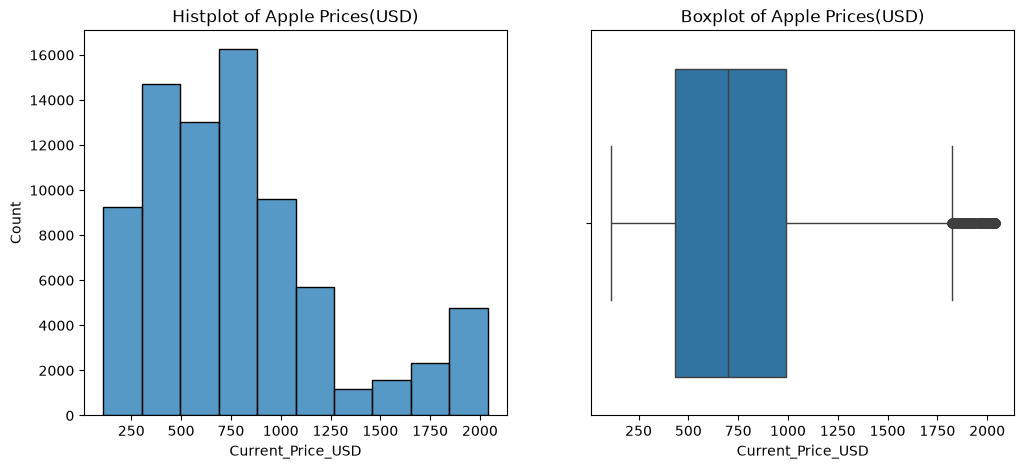

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(data=data, x="Current_Price_USD", ax=axes[0], bins=10)
axes[0].set_title("Histplot of Apple Prices(USD)")
sns.boxplot(data=data, x="Current_Price_USD", ax=axes[1])
axes[1].set_title("Boxplot of Apple Prices(USD)")
plt.show()


In [19]:
q1, q3 = data["Current_Price_USD"].quantile(0.25), data["Current_Price_USD"].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
iqr_outliers = data[(data["Current_Price_USD"] < lower) | (data["Current_Price_USD"] > upper)]
iqr_outliers.shape[0]

4973

In [20]:
data["Current_Price_USD"].skew()

np.float64(1.109496867246592)

<Axes: >

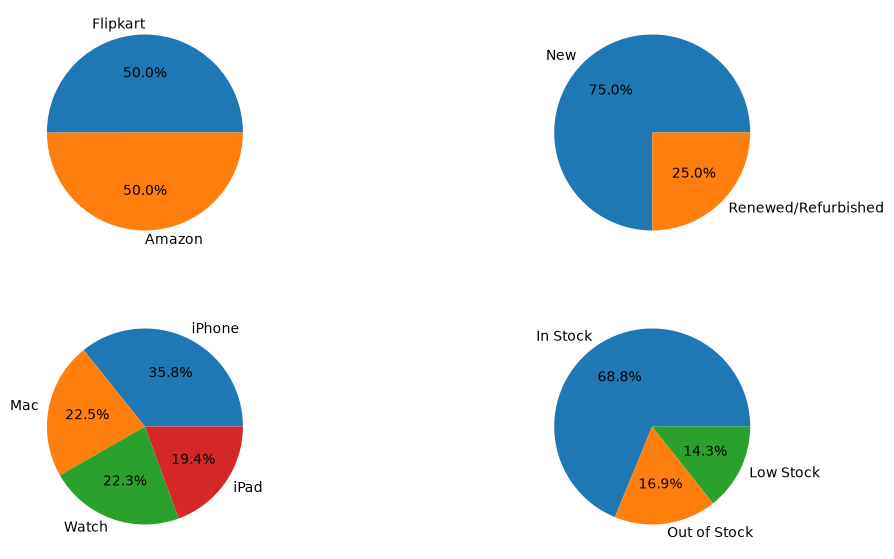

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

data["Platform"].value_counts(normalize=True).plot.pie(autopct="%1.1f%%", ax=axes[0][0])
data["Product_Category"].value_counts(normalize=True).plot.pie(autopct="%1.1f%%", ax=axes[1][0])
data["Condition"].value_counts(normalize=True).plot.pie(autopct="%1.1f%%", ax=axes[0][1])
data["Stock_Status"].value_counts(normalize=True).plot.pie(autopct="%1.1f%%",ax=axes[1][1] )

#### Here is what we found in Step 3:
1. Mean > Median → probable skewness, confirmed by |skew| ≥ 1: the price distribution is highly right-skewed, meaning a small number of very high prices are pulling the mean above what a typical product actually costs.
2. Based on the IQR method, 4,973 rows out of 78,400 are outliers — these are the high-end listings (likely MacBook models) that stretch the right tail of the distribution.
3. The histogram and boxplot together show that most current prices sit between $433–$990 USD, with a long tail of expensive products pushing the mean upward.
4. The 4 pie charts tell us:
    - Platform: an exact 50/50 split between Amazon and Flipkart — suspiciously clean, and worth keeping in mind as a possible sign that this dataset was generated rather than scraped from real listings.
    - Condition: new products make up 75% of listings, roughly three times more than renewed or refurbished ones.
    - Product Category: iPhone leads at 35.8% while iPad is the smallest category at 19.4%, though all four categories are relatively close in proportion.
    - Stock Status: 68.8% of products are in stock, with the remaining 31.2% split between out-of-stock and low-stock listings.

## Step 4 - Compare groups:

### Questions:
1. Does the price gap between product categories (Mac vs iPhone vs iPad etc.) stay consistent across platforms, or does one platform price certain categories differently?
2. What Product Category gets the highest Discount percentage
3.  ?
4. What Product category raised its price the most in every year ?

#### Question 1: Does the price gap between product categories (Mac vs iPhone vs iPad etc.) stay consistent across platforms, or does one platform price certain categories differently?

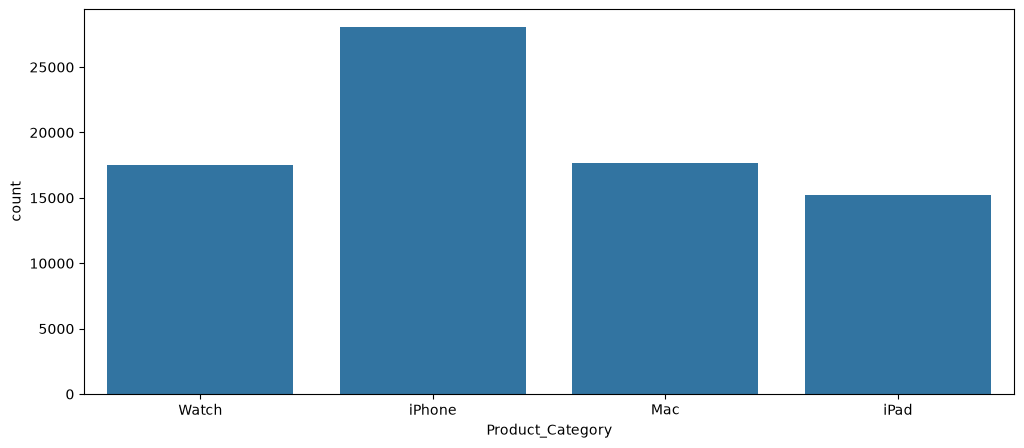

In [22]:
fig, ax = plt.subplots(figsize=(12,5))
sns.countplot(data=data, x="Product_Category", ax=ax)
plt.show()

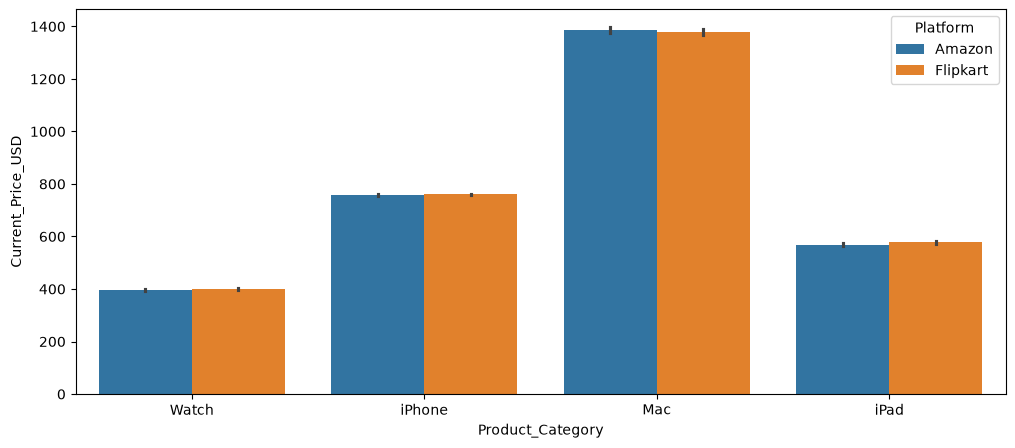

In [23]:
fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(data=data, x="Product_Category", y="Current_Price_USD", hue="Platform", ax=ax)
plt.show()

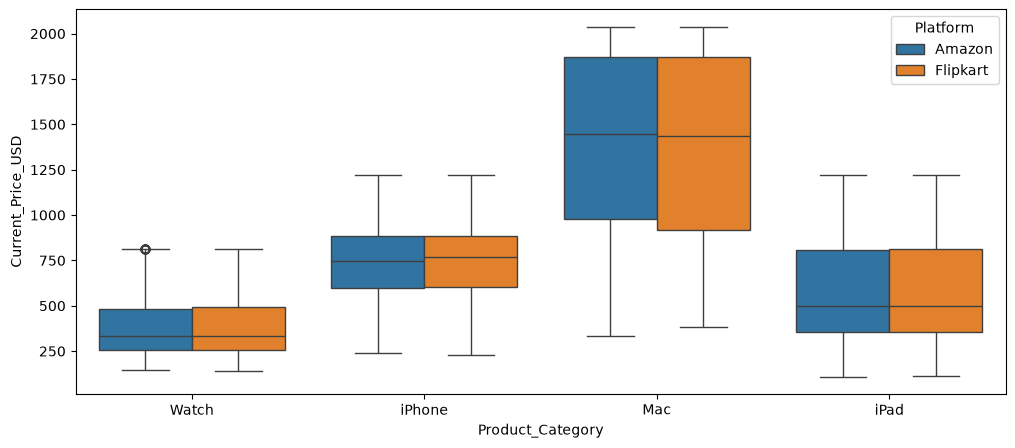

In [24]:
fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(data=data, x="Product_Category", y="Current_Price_USD", hue="Platform", ax=ax)
plt.show()

In [25]:
data.groupby("Platform")["Current_Price_USD"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)

,mean,std,count
Platform,,,
Amazon,783.880178,464.2968,39188
Flipkart,782.158943,459.1555,39212


###### Effect size: 

In [26]:
s = data.groupby("Platform")["Current_Price_USD"].mean()
mean_am = s["Amazon"].mean()
mean_flip = s["Flipkart"].mean()
std = data["Current_Price_USD"].std()
ef = (mean_am - mean_flip)/ std
print(ef)

0.0037277933913377743


#### Question 1 Answer: Does price differ by platform, within each product category?

- Across all four categories, Amazon and Flipkart prices are effectively identical — the largest gap is iPad at ~USD8.90 (Amazon USD569 vs Flipkart USD578), and the smallest is Mac at USD5.40.
- Effect size confirms this per category, not just in aggregate: Watch −0.017, iPhone −0.015, Mac 0.011, iPad −0.031 — all far below the 0.2 threshold for even a small effect.
- This rules out a real risk with pooled averages: category mix differing between platforms could in principle hide a per-category gap behind a misleading overall number. Checking each category individually confirms that's not happening here — there's no meaningful platform-based pricing at all, at either the aggregate or category level.
- Sample sizes are large on both platforms (~39,000 rows each), so this isn't a small-n artifact either.

#### Question 2: What Product Category gets the highest Discount percentage?

In [27]:
data.groupby("Product_Category")["Discount_Pct"].agg(["median", "mean", "std", "count"]).sort_values("median", ascending = False)

,median,mean,std,count
Product_Category,,,,
iPad,28.55,26.174941,17.148072,15208
Watch,24.90,26.246758,17.440939,17490
iPhone,18.00,19.572224,16.149315,28035
Mac,11.20,15.443080,13.608545,17667


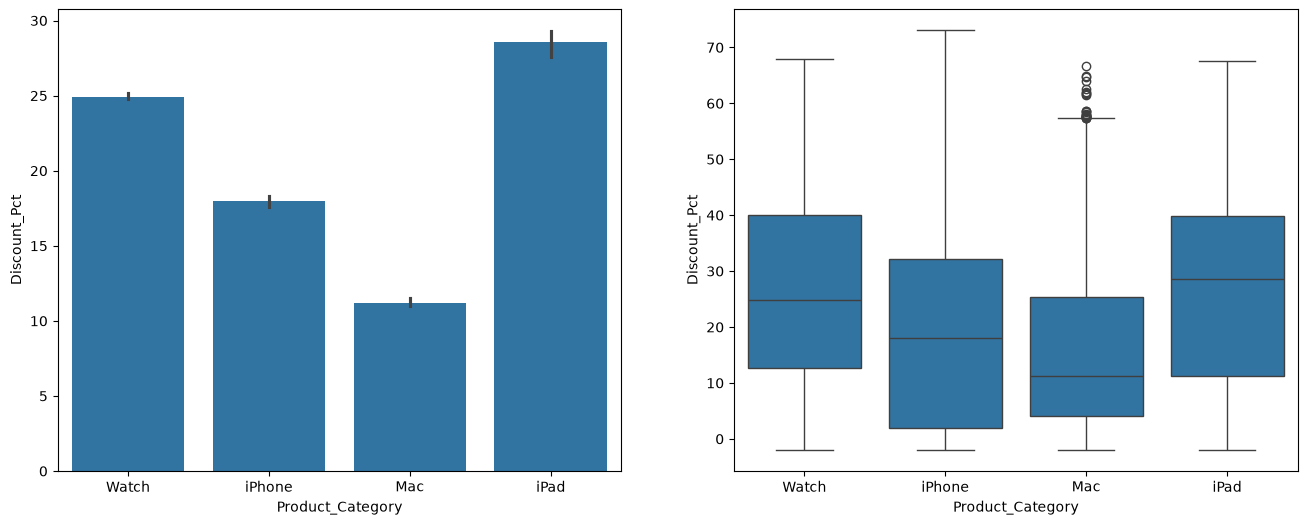

In [28]:
fig, axes  = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=data, x="Product_Category", y ="Discount_Pct", estimator="median", ax=axes[0])
sns.boxplot(data=data, x="Product_Category", y ="Discount_Pct", ax=axes[1])
plt.show()

#### Question 2 Answer: What Product Category gets the highest Discount percentage ?
- By median, iPad (28.55%) and Watch (24.90%) sit at the top with no real separation between them — effect size 0.21 (small), meaning these two aren't meaningfully different from each other, just a close pair leading together.
- iPhone (18.00%) sits clearly below that top pair — effect size ≈0.41 vs Watch (moderate, real gap).
- Mac (11.20%) is the clear lowest — effect size ≈0.45 vs iPhone (moderate, real gap).
- So the honest structure is three tiers, not four ranked categories: {iPad, Watch} > iPhone > Mac, with a real, meaningful gap between each tier.
- Mac's distribution is notably right-skewed — its mean (15.44%) sits 4.2 points above its median (11.20%), the largest mean-median gap of any category — meaning a small number of high-discount Mac listings pull the average up above what a typical listing actually gets.
- All group sizes are large (15,208–28,035 rows per category), so this ranking isn't a small-sample artifact — the tiers reflect a real pattern, not noise.

### Question 3: What Product category raised its price the most in every year ?

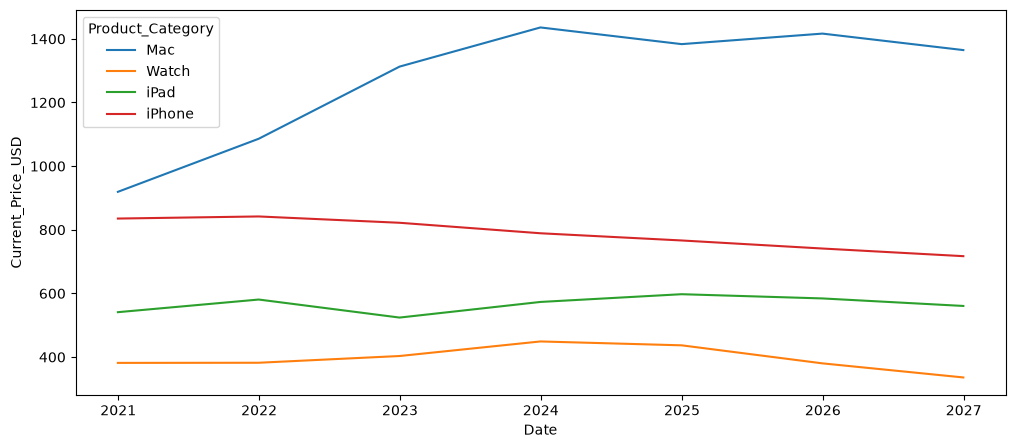

In [29]:
yearly = data.groupby(["Product_Category", pd.Grouper(key="Date", freq="YE")])["Current_Price_USD"].mean().reset_index()


fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(data=yearly, x="Date", y="Current_Price_USD", hue="Product_Category", ax=ax)
plt.show()

In [30]:
data.set_index("Date").resample("YE")["Current_Price_USD"].agg(["mean", "median", "std","count"]).reset_index()

,Date,mean,median,std,count
0,2020-12-31,663.248150,611.240,236.476061,454
1,2021-12-31,721.152152,722.870,309.240951,3211
2,2022-12-31,743.343212,690.340,415.133221,6869
3,2023-12-31,794.206482,701.485,474.250652,11414
4,2024-12-31,802.172694,706.050,470.598567,17824
5,2025-12-31,799.525763,700.130,485.387154,23693
6,2026-12-31,760.615424,691.760,451.987199,14935


In [31]:
data.groupby(["Product_Category", pd.Grouper(key="Date", freq="YE")])["Current_Price_USD"].agg(["mean", "median", "std", "count"]).reset_index()

,Product_Category,Date,mean,median,std,count
0,Mac,2020-12-31,919.226842,986.610,112.563265,57
1,Mac,2021-12-31,1086.058876,995.785,378.362152,516
2,Mac,2022-12-31,1312.774006,1194.605,488.193177,1248
3,Mac,2023-12-31,1435.850196,1496.145,492.582772,2400
4,Mac,2024-12-31,1383.411856,1397.860,477.546026,4262
5,Mac,2025-12-31,1416.501869,1524.070,483.023825,5822
6,Mac,2026-12-31,1364.689967,1512.740,473.221703,3362
7,Watch,2020-12-31,381.589187,390.540,51.689059,123
8,Watch,2021-12-31,382.045970,422.880,61.806440,608
9,Watch,2022-12-31,403.230508,353.060,153.756751,1299


#### Question 3 Answer: What Product category raised its price the most in every year ?

Mac is the only product category whose average price rose over the observed period (~$919 → ~$1,364), while iPhone and Watch declined and iPad stayed roughly flat. This trend should be read with caution: 2020 has very low sample size (n=57 for Mac) and may not represent a full year of data, and category averages can shift due to changing model composition over time (newer, higher-tier Mac models entering later years) rather than existing models actually getting more expensive — this wasn't fully verified against Model_Name and is noted as a limitation.

## Step 5 - Explore relationships

### Questions:
4. Is Discount percentage causes direcly the amount of reviews.
7. do higher-rated items also cost more ?

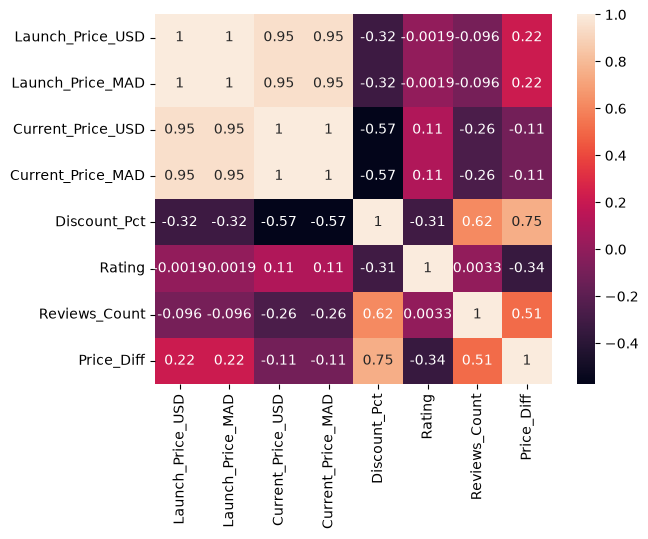

In [32]:
fig, ax = plt.subplots()
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

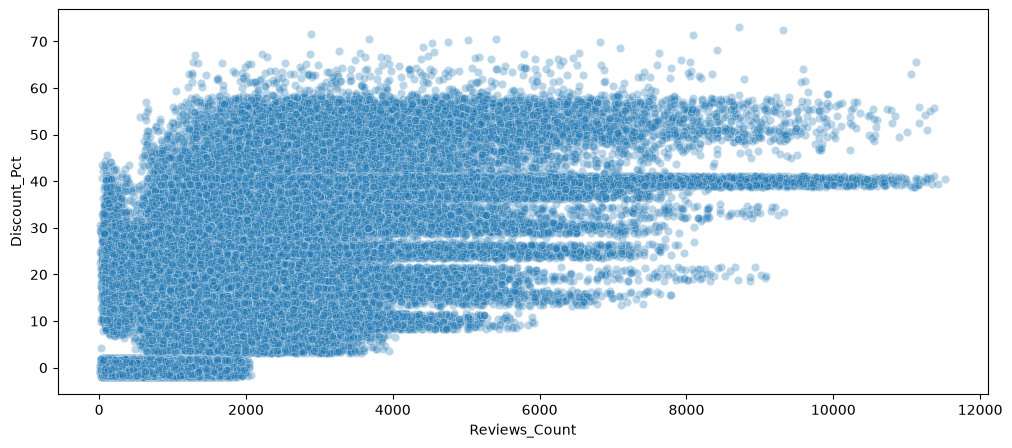

In [33]:
fig,  ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=data, x="Reviews_Count", y="Discount_Pct", alpha=0.3, ax=ax)
plt.show()

### Question 4 Answer: 4. Is Discount percentage causes direcly the amount of reviews?
Looking at the scatter plot, there's no perfect line here, but there is a clear pattern: items with very few reviews have discounts all over the place, anywhere from 0% to 70%. But once an item has a lot of reviews, low discounts basically disappear — you almost never see a highly-reviewed item with a tiny discount. That's why the correlation number (r=0.62, a fairly strong link) shows up, even though the dots don't form a neat straight line.

But this doesn't mean discounts cause people to leave more reviews. There's a simpler explanation that fits just as well: an item that's been listed for a long time has had more time to do two things — build up reviews naturally, and get marked down by the seller as it ages on the shelf. So "how long the item has existed" could be quietly driving both numbers, and the discount itself might have nothing to do with it. We don't have a "how long has this been listed" column in this dataset to actually check that, so this stays a possible explanation, not a proven one — but it's the more believable story than "discounts excite buyers into reviewing."

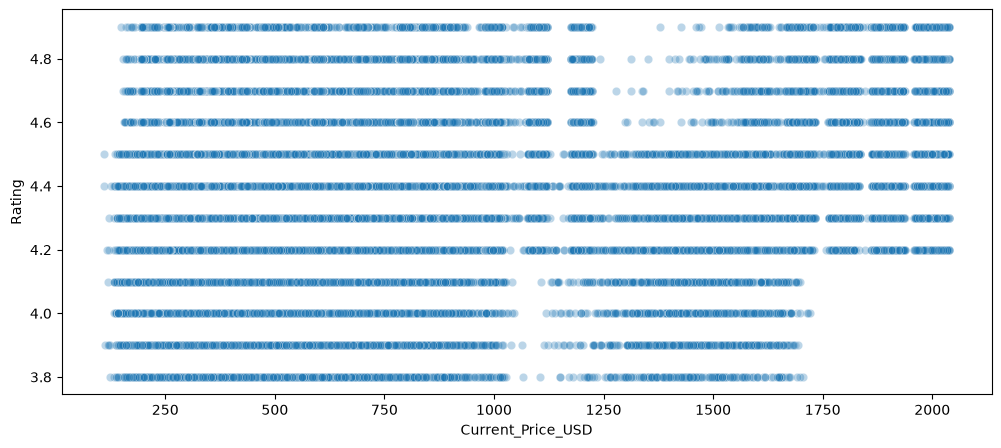

In [34]:
fig,  ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=data, x="Current_Price_USD", y="Rating", alpha=0.3, ax=ax)
plt.show()

### Question 5 Answer: Do higher-rated items also cost more ?
Scatter plot of Current_Price_USD vs Rating shows no visible relationship — for every rating level, prices span nearly the full range ($150–$2000+), with no diagonal trend or clustering. This visually confirms the earlier correlation number (r=0.11): price and rating are essentially independent in this dataset. In plain terms — expensive items aren't rated meaningfully better or worse than cheap ones.